**Introducción a la base de datos**

La **tuberculosis** es una enfermedad infectocontagiosa de etiología bacteriana causada principalmente por el microorganismo Mycobacterium tuberculosis el cual afecta predominantemente el parénquima pulmonar aunque posee la capacidad de diseminarse por vía hematógena hacia otros órganos sistémicos como los riñones o el sistema nervioso central provocando una respuesta inflamatoria granulomatosa que se manifiesta mediante síntomas persistentes como tos con expectoración hemoptoica y una marcada pérdida de peso involuntaria acompañada de sudoración nocturna y fatiga crónica

***Cuadro Clínico (Síntomas Clave)***
Si un paciente presenta la siguiente sintomatología por más de 15 días, debe considerarse un "sintomático respiratorio":

Tos persistente: Generalmente con expectoración

(flemas) que puede contener sangre (hemoptisis).

Sudoración nocturna: Empapar la ropa de cama sin una causa ambiental aparente.

Pérdida de peso involuntaria: Junto con una marcada falta de apetito (anorexia).

Fiebre vespertina: Alzas térmicas leves que suelen aparecer por la tarde o noche.

Fatiga crónica: Un cansancio extremo que no mejora con el descanso.

Diagnóstico y Tratamiento
¿Cómo la detectamos?
Baciloscopia (BK en esputo): Análisis de la flema bajo el microscopio para buscar el bacilo.

Pruebas moleculares (GeneXpert): Permiten detectar el ADN de la bacteria y su resistencia a medicamentos en pocas horas.

Radiografía de Tórax: Para observar lesiones, cavernas o infiltrados en los pulmones.

El Tratamiento
Afortunadamente, la tuberculosis es curable. El tratamiento estándar consiste en una combinación de antibióticos específicos (como Isoniazida, Rifampicina, Etambutol y Pirazinamida) administrados durante un periodo mínimo de 6 meses.

El mayor desafío clínico es la adherencia: si el paciente suspende el tratamiento antes de tiempo porque "ya se siente bien", se corre el riesgo de generar Tuberculosis Multirresistente (TB-MDR), la cual es mucho más difícil y costosa de tratar.

In [59]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Sección 1** — Exploración Inicial de Datos (1. Carga y Diagnóstico de los Datasets)

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── CARGA ──────────────────────────────────────────────────
pop = pd.read_csv('/content/drive/MyDrive/Python/population.csv')
who = pd.read_csv('/content/drive/MyDrive/Python/who.csv')

# ── EXPLORACIÓN RÁPIDA ─────────────────────────────────────
for nombre, df in [("POBLACIÓN", pop), ("WHO", who)]:
    print(f"\n{'='*55}")
    print(f"{nombre}")
    print(f"{'='*55}")
    print(f"  Filas × Columnas : {df.shape}")
    print(f"\n  Columnas:\n{df.dtypes.to_string()}")
    print(f"\n  Primeras 3 filas:")
    display(df.head(3))
    print(f"\n  Estadísticas básicas:")
    display(df.describe(include='all'))
    print(f"\n  Valores nulos por columna:")
    nulos = df.isnull().sum()
    display(nulos[nulos > 0] if nulos.any() else pd.Series({"Sin nulos": 0}))


POBLACIÓN
  Filas × Columnas : (4060, 3)

  Columnas:
country       object
year           int64
population     int64

  Primeras 3 filas:


,country,year,population
0,Afghanistan,1995,17586073
1,Afghanistan,1996,18415307
2,Afghanistan,1997,19021226



  Estadísticas básicas:


,country,year,population
count,4060,4060.000000,4.060000e+03
unique,219,NaN,NaN
top,Afghanistan,NaN,NaN
freq,19,NaN,NaN
mean,NaN,2004.042118,3.003344e+07
std,NaN,5.483784,1.213473e+08
min,NaN,1995.000000,1.129000e+03
25%,NaN,1999.000000,6.029192e+05
50%,NaN,2004.000000,5.318854e+06
75%,NaN,2009.000000,1.855416e+07



  Valores nulos por columna:


...

,country,iso2,iso3,year,new_sp_m014,new_sp_m1524,new_sp_m2534,new_sp_m3544,new_sp_m4554,new_sp_m5564,new_sp_m65,new_sp_f014,new_sp_f1524,new_sp_f2534,new_sp_f3544,new_sp_f4554,new_sp_f5564,new_sp_f65,new_sn_m014,new_sn_m1524,new_sn_m2534,new_sn_m3544,new_sn_m4554,new_sn_m5564,new_sn_m65,new_sn_f014,new_sn_f1524,new_sn_f2534,new_sn_f3544,new_sn_f4554,new_sn_f5564,new_sn_f65,new_ep_m014,new_ep_m1524,new_ep_m2534,new_ep_m3544,new_ep_m4554,new_ep_m5564,new_ep_m65,new_ep_f014,new_ep_f1524,new_ep_f2534,new_ep_f3544,new_ep_f4554,new_ep_f5564,new_ep_f65,newrel_m014,newrel_m1524,newrel_m2534,newrel_m3544,newrel_m4554,newrel_m5564,newrel_m65,newrel_f014,newrel_f1524,newrel_f2534,newrel_f3544,newrel_f4554,newrel_f5564,newrel_f65
0,Afghanistan,AF,AFG,1980,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AF,AFG,1981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AF,AFG,1982,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



  Estadísticas básicas:


,country,iso2,iso3,year,new_sp_m014,new_sp_m1524,new_sp_m2534,new_sp_m3544,new_sp_m4554,new_sp_m5564,new_sp_m65,new_sp_f014,new_sp_f1524,new_sp_f2534,new_sp_f3544,new_sp_f4554,new_sp_f5564,new_sp_f65,new_sn_m014,new_sn_m1524,new_sn_m2534,new_sn_m3544,new_sn_m4554,new_sn_m5564,new_sn_m65,new_sn_f014,new_sn_f1524,new_sn_f2534,new_sn_f3544,new_sn_f4554,new_sn_f5564,new_sn_f65,new_ep_m014,new_ep_m1524,new_ep_m2534,new_ep_m3544,new_ep_m4554,new_ep_m5564,new_ep_m65,new_ep_f014,new_ep_f1524,new_ep_f2534,new_ep_f3544,new_ep_f4554,new_ep_f5564,new_ep_f65,newrel_m014,newrel_m1524,newrel_m2534,newrel_m3544,newrel_m4554,newrel_m5564,newrel_m65,newrel_f014,newrel_f1524,newrel_f2534,newrel_f3544,newrel_f4554,newrel_f5564,newrel_f65
count,7240,7206,7240,7240.000000,3173.000000,3209.000000,3206.000000,3219.000000,3223.000000,3218.000000,3209.000000,3174.000000,3194.000000,3200.000000,3199.000000,3204.000000,3195.000000,3197.000000,1045.000000,1030.000000,1022.000000,1025.000000,1027.000000,1021.000000,1020.000000,1040.000000,1022.000000,1016.000000,1020.000000,1018.000000,1017.000000,1019.000000,1038.000000,1026.000000,1020.000000,1024.000000,1020.000000,1015.000000,1018.000000,1032.000000,1021.000000,1021.000000,1021.000000,1017.000000,1017.000000,1014.000000,190.000000,182.000000,183.000000,184.000000,184.000000,185.000000,182.000000,190.000000,184.000000,182.000000,183.000000,183.000000,183.000000,185.000000
unique,219,218,219,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Afghanistan,AF,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,34,34,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,1996.556768,83.710054,1015.660019,1403.800998,1315.884747,1103.857276,800.698881,682.818947,114.328607,826.111772,917.304375,640.429822,445.779963,313.867919,283.932749,308.745455,513.022330,653.686888,837.865366,520.788705,448.620960,460.356863,291.951923,407.899217,466.261811,506.589216,271.158153,213.391347,230.750736,128.611753,158.295322,201.228431,272.715820,108.107843,72.165517,78.936149,112.886628,149.172380,189.524976,241.704212,93.768928,63.036382,72.307692,538.178947,1489.505495,2139.721311,2036.396739,1835.070652,1525.302703,1426.000000,532.836842,1161.853261,1472.802198,1125.010929,877.267760,686.409836,683.762162
std,NaN,NaN,NaN,9.828904,316.136459,4885.378588,5718.387178,6003.260603,5441.061415,4418.309010,4089.137785,504.633674,3552.024632,3580.151198,2542.507349,1799.227814,1381.250117,1267.936069,1727.253688,3643.272574,3430.030331,8524.529853,3301.696749,3488.684589,3991.903870,1647.302710,2379.126655,2272.857327,5013.534472,1511.717689,1468.622765,1597.703255,460.143723,537.736716,764.053987,3381.409958,380.607244,234.554549,227.338197,446.546995,543.893049,761.793602,3218.496057,339.326778,212.945997,202.720271,2082.180750,6848.181170,7539.871720,7847.942334,8324.282351,8760.267951,9431.992775,2117.777714,4606.763119,5259.592231,4210.577991,3556.178992,3379.328224,3618.471096
min,NaN,NaN,NaN,1980.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0


  Valores nulos por columna:


,0
iso2,34
new_sp_m014,4067
new_sp_m1524,4031
new_sp_m2534,4034
new_sp_m3544,4021
new_sp_m4554,4017
new_sp_m5564,4022
new_sp_m65,4031
new_sp_f014,4066
new_sp_f1524,4046


RESUMEN DEL ANALISIS


EXPLORACION DE ESTILOS

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# EXPLORACION DE ESTILOS
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({'figure.dpi': 130, 'font.family': 'DejaVu Sans'})

In [62]:
#Carga de documentos
pop = pd.read_csv('/content/drive/MyDrive/Python/population.csv')
who = pd.read_csv('/content/drive/MyDrive/Python/who.csv')

In [63]:
#LIMPIEZA / TIDY DEL WHO: Convertimos las 56 columnas de casos en filas
who_tidy = who.melt(
    id_vars=['country', 'iso2', 'iso3', 'year'],
    var_name='key', value_name='cases'
).dropna(subset=['cases'])

#Parsear el key: tipo_sexo_edad

In [64]:
#Parsearl key: tipo de sexo edad
who_tidy['key'] = who_tidy['key'].str.replace('newrel', 'new_rel', regex=False)
who_tidy[['new', 'type', 'sexage']] = who_tidy['key'].str.split('_', expand=True)
who_tidy['sex']     = who_tidy['sexage'].str[0]          # m / f
who_tidy['age']     = who_tidy['sexage'].str[1:]          # 014, 1524...
who_tidy = who_tidy.drop(columns=['key', 'new', 'sexage'])
who_tidy['cases']   = who_tidy['cases'].astype(int)

Forma/dimensión del dataframe WHO

In [65]:
print("forma/dimensión del dataframe WHO", who_tidy.shape)
display(who_tidy.head())

forma/dimensión del dataframe WHO (76046, 8)


,country,iso2,iso3,year,cases,type,sex,age
17,Afghanistan,AF,AFG,1997,0,sp,m,014
18,Afghanistan,AF,AFG,1998,30,sp,m,014
19,Afghanistan,AF,AFG,1999,8,sp,m,014
20,Afghanistan,AF,AFG,2000,52,sp,m,014
21,Afghanistan,AF,AFG,2001,129,sp,m,014


Margen con poblacion (años en comun: 1995-2013)

In [66]:
df = who_tidy.merge(pop, on=['country', 'year'], how='inner')
df['rate'] = df['cases'] / df['population'] * 100_000  # casos por 100k hab

# Totales por país-año
by_country_year = (df.groupby(['country', 'year'])
                     .agg(total_cases=('cases','sum'),
                          population=('population','first'))
                     .reset_index())
by_country_year['rate'] = by_country_year['total_cases'] / by_country_year['population'] * 100_000

print("\nMerge listo:", df.shape)


Merge listo: (75234, 10)


**GRAFICAS**

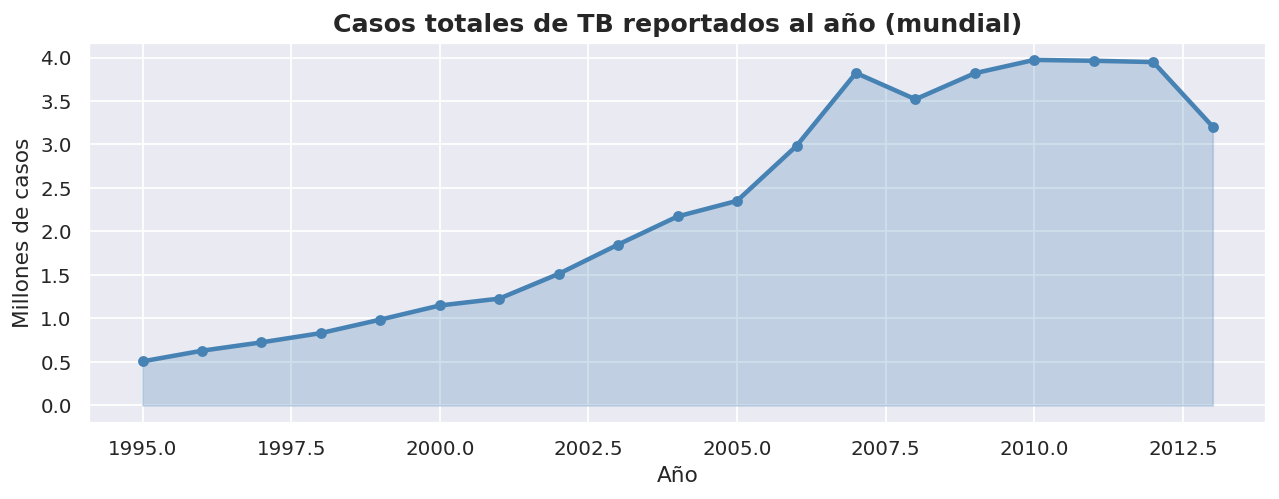

In [67]:
#Tendencia global de casos totales
global_trend = by_country_year.groupby('year')['total_cases'].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(global_trend['year'], global_trend['total_cases']/1e6,
                alpha=0.25, color='steelblue')
ax.plot(global_trend['year'], global_trend['total_cases']/1e6,
        color='steelblue', lw=2.5, marker='o', ms=5)
ax.set_title('Casos totales de TB reportados al año (mundial)', fontsize=14, fontweight='bold')
ax.set_ylabel('Millones de casos')
ax.set_xlabel('Año')
plt.tight_layout(); plt.show()

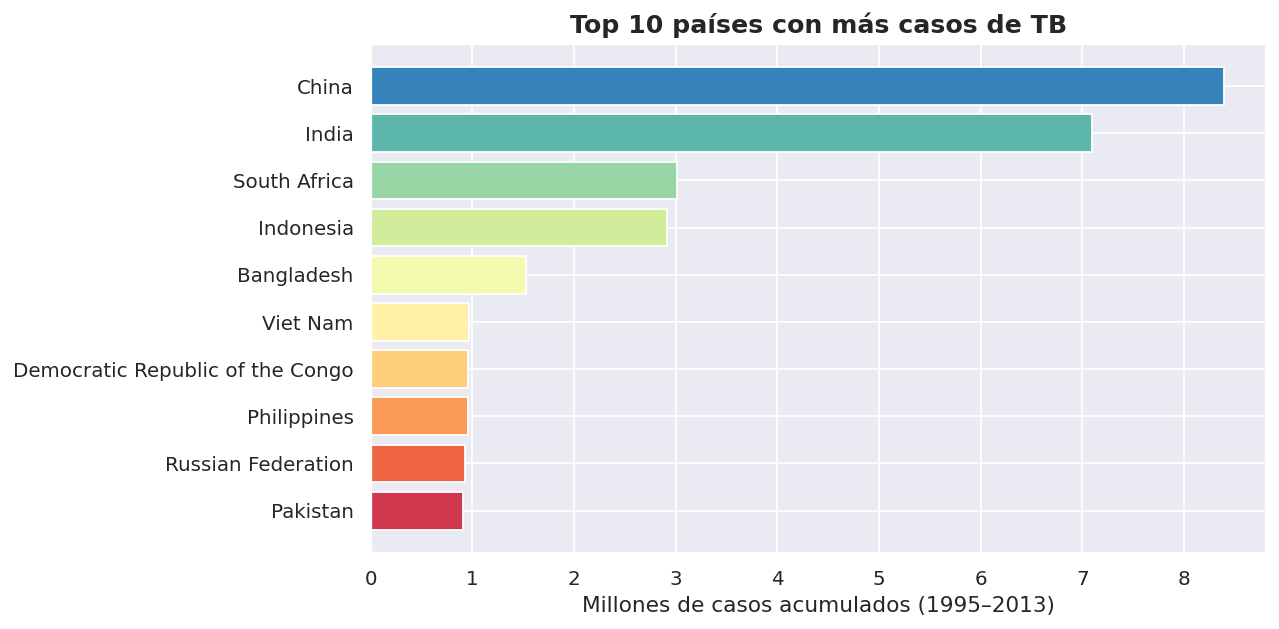

In [68]:
# ── 4.2  Top 10 países con más casos acumulados ───────────
top10 = (by_country_year.groupby('country')['total_cases']
                         .sum()
                         .nlargest(10)
                         .reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top10['country'][::-1], top10['total_cases'][::-1]/1e6,
               color=sns.color_palette("Spectral", 10))
ax.set_xlabel('Millones de casos acumulados (1995–2013)')
ax.set_title('Top 10 países con más casos de TB', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

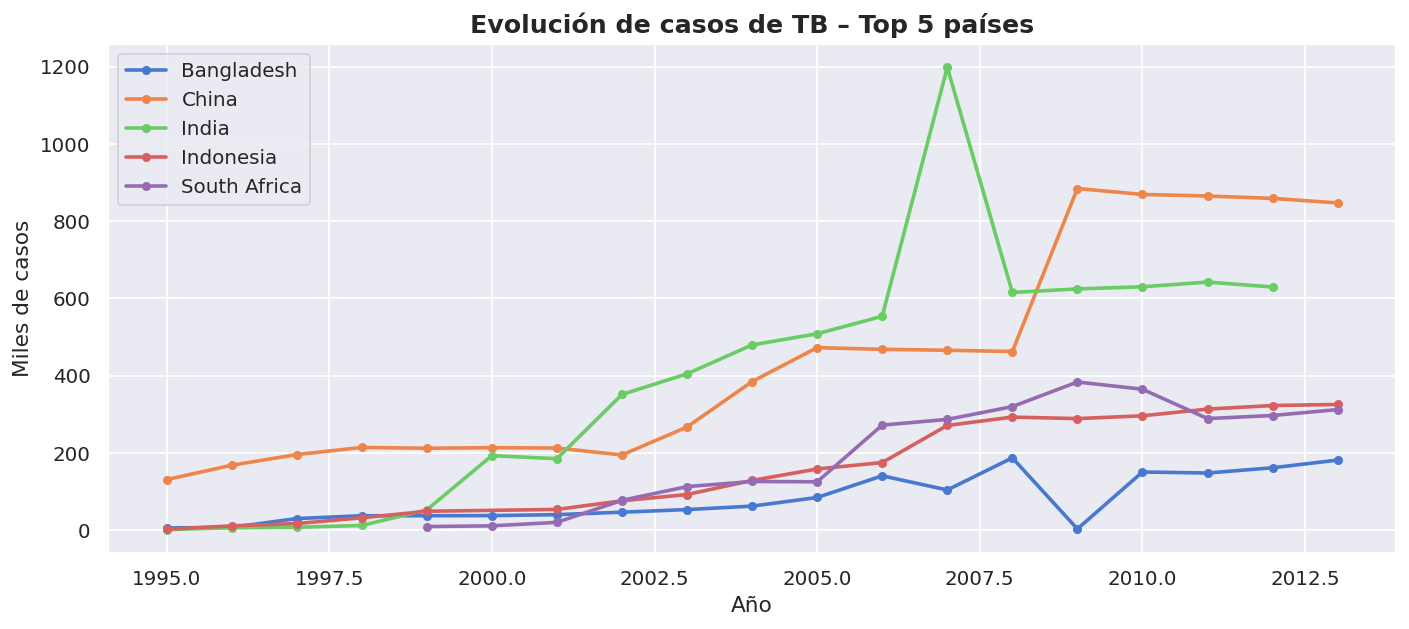

In [69]:
#Evolución de los 5 países con más carga
top5 = top10['country'].head(5).tolist()
df5  = by_country_year[by_country_year['country'].isin(top5)]

fig, ax = plt.subplots(figsize=(11, 5))
for pais, grp in df5.groupby('country'):
    ax.plot(grp['year'], grp['total_cases']/1e3, marker='o', ms=4, label=pais, lw=2)
ax.set_title('Evolución de casos de TB – Top 5 países', fontsize=14, fontweight='bold')
ax.set_ylabel('Miles de casos')
ax.set_xlabel('Año')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

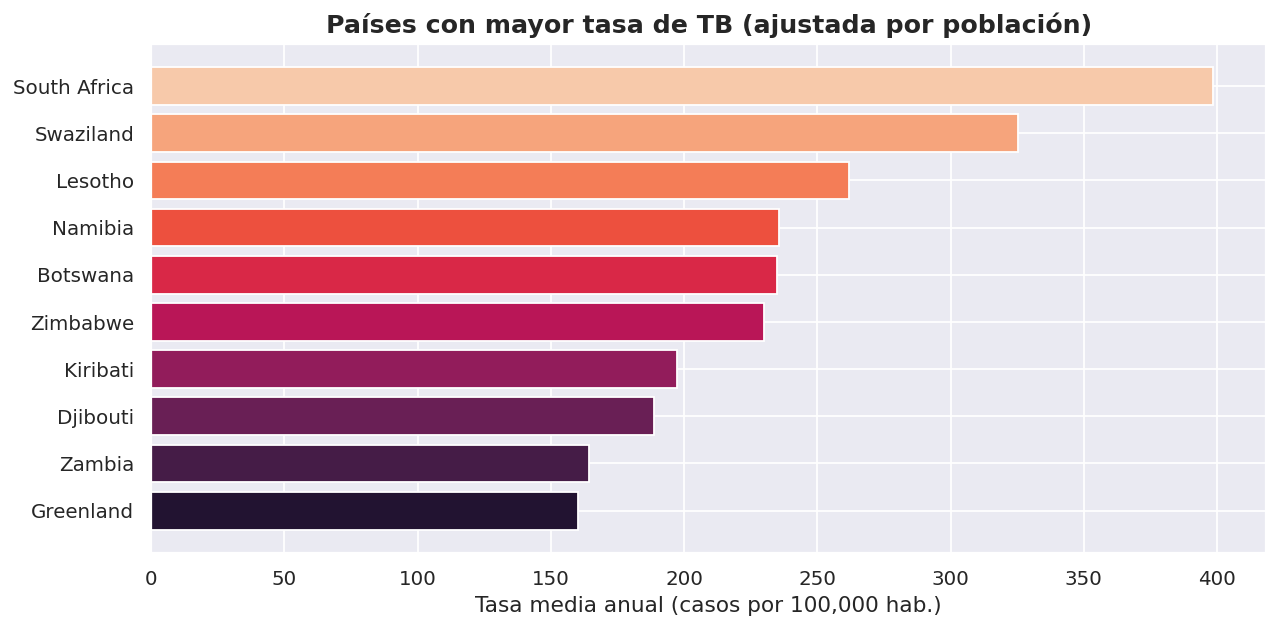

In [70]:
#Tasa por 100k habitantes (top 10)
rate_top10 = (by_country_year.groupby('country')['rate']
                              .mean()
                              .nlargest(10)
                              .reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(rate_top10['country'][::-1], rate_top10['rate'][::-1],
        color=sns.color_palette("rocket", 10))
ax.set_xlabel('Tasa media anual (casos por 100,000 hab.)')
ax.set_title('Países con mayor tasa de TB (ajustada por población)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

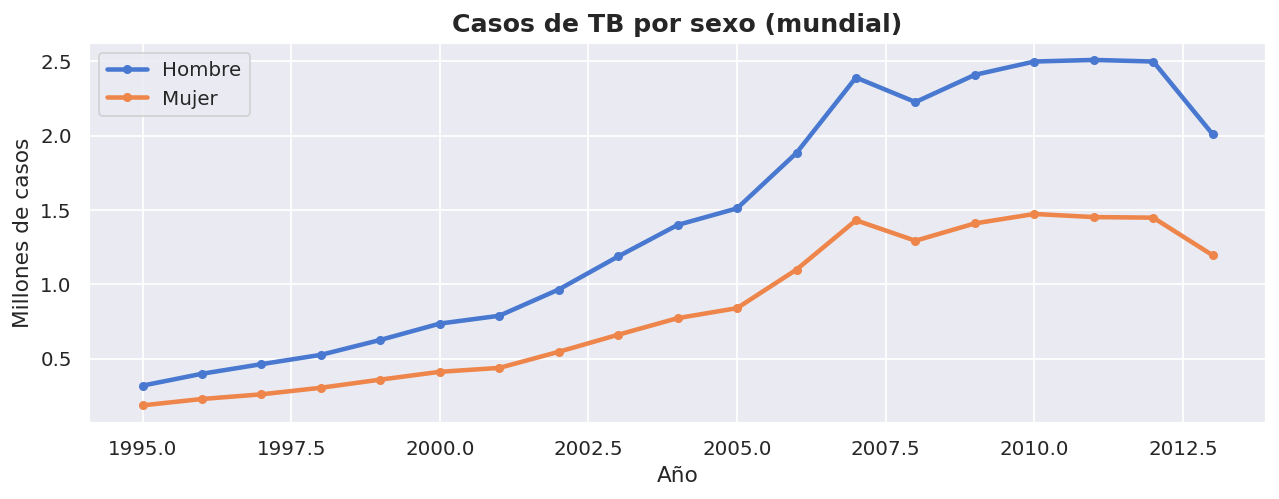

In [71]:
#Casos por sexo (global)
by_sex = (df.groupby(['year','sex'])['cases'].sum().reset_index())
by_sex['sex'] = by_sex['sex'].map({'m':'Hombre','f':'Mujer'})

fig, ax = plt.subplots(figsize=(10, 4))
for s, grp in by_sex.groupby('sex'):
    ax.plot(grp['year'], grp['cases']/1e6, marker='o', ms=4, label=s, lw=2.5)
ax.set_title('Casos de TB por sexo (mundial)', fontsize=14, fontweight='bold')
ax.set_ylabel('Millones de casos'); ax.set_xlabel('Año')
ax.legend(); plt.tight_layout(); plt.show()

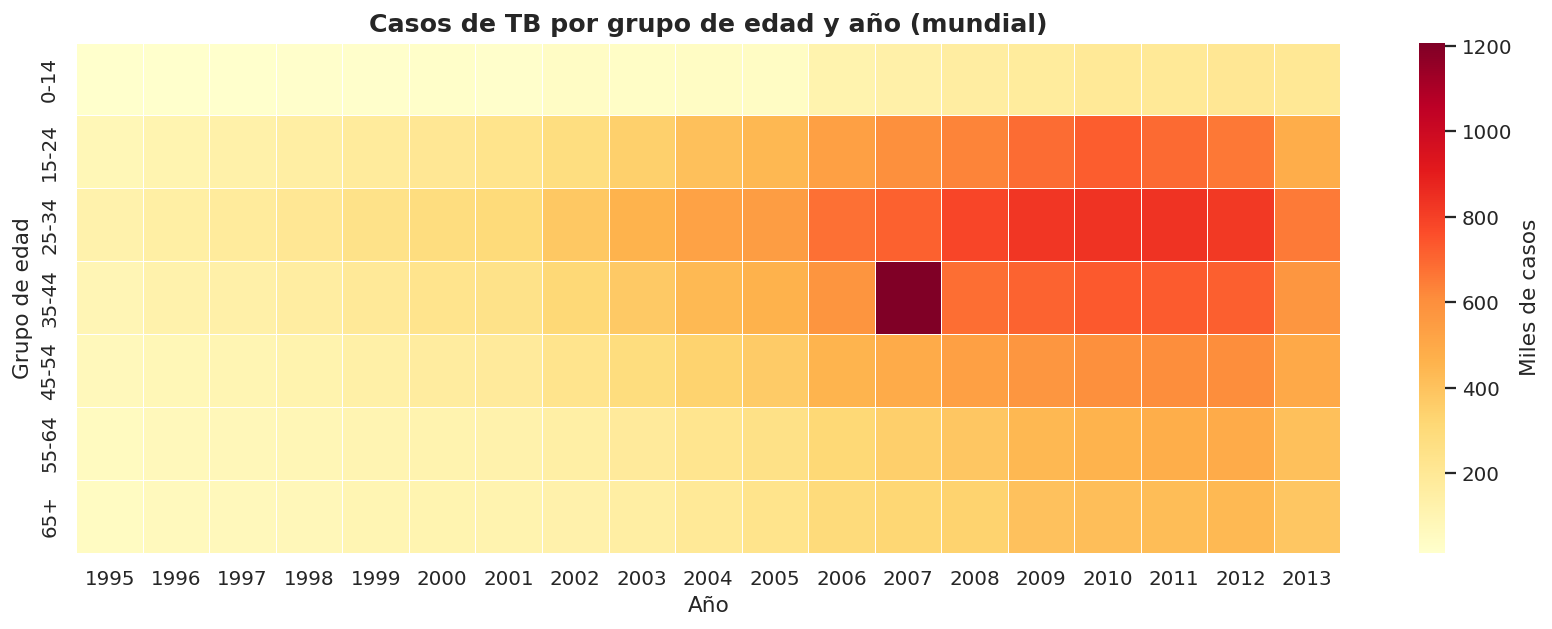

In [72]:
#Distribución por grupo de edad (heatmap)
age_labels = {'014':'0-14','1524':'15-24','2534':'25-34',
              '3544':'35-44','4554':'45-54','5564':'55-64','65':'65+'}
by_age = (df.groupby(['year','age'])['cases'].sum().reset_index())
by_age['age'] = by_age['age'].map(age_labels)
pivot = by_age.pivot(index='age', columns='year', values='cases').fillna(0)
order = ['0-14','15-24','25-34','35-44','45-54','55-64','65+']
pivot = pivot.reindex([a for a in order if a in pivot.index])

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(pivot/1e3, cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label':'Miles de casos'}, ax=ax)
ax.set_title('Casos de TB por grupo de edad y año (mundial)', fontsize=14, fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Grupo de edad')
plt.tight_layout(); plt.show()

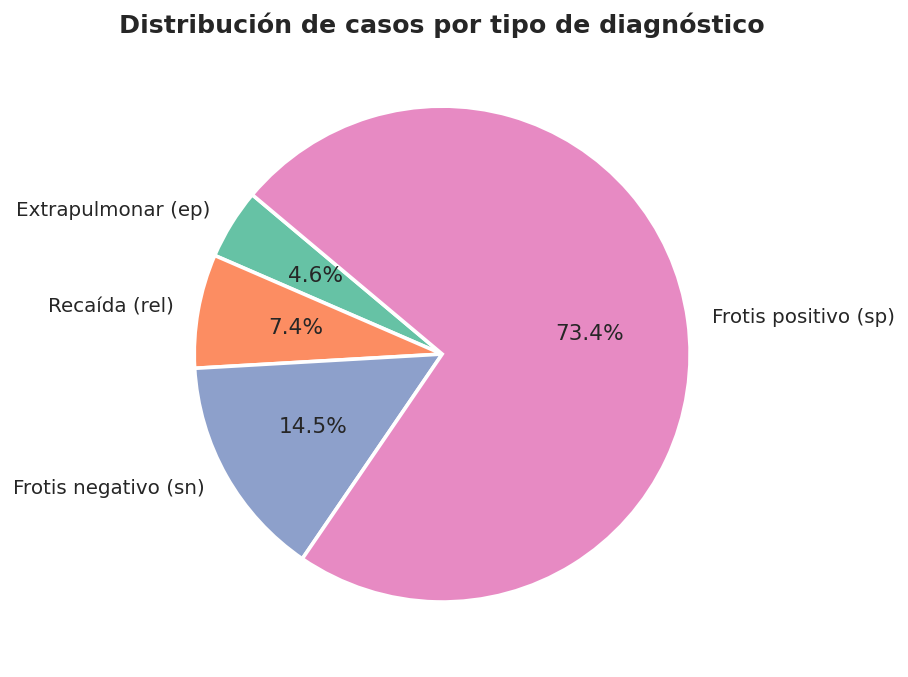

In [73]:
#Casos por tipo de diagnóstico
type_labels = {'sp':'Frotis positivo (sp)',
               'sn':'Frotis negativo (sn)',
               'ep':'Extrapulmonar (ep)',
               'rel':'Recaída (rel)'}
by_type = df.groupby('type')['cases'].sum().reset_index()
by_type['type'] = by_type['type'].map(type_labels)

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(by_type['cases'], labels=by_type['type'], autopct='%1.1f%%',
       startangle=140, colors=sns.color_palette("Set2", 4),
       wedgeprops={'edgecolor':'white','linewidth':2})
ax.set_title('Distribución de casos por tipo de diagnóstico', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

**Sección 2** — Limpieza, Integración y Análisis Visual ("2. Transformación Tidy, Merge y Visualización")

In [74]:
file_path = '/content/drive/MyDrive/Python/population.csv'
df = pd.read_csv(file_path)
display(df.head())

,country,year,population
0,Afghanistan,1995,17586073
1,Afghanistan,1996,18415307
2,Afghanistan,1997,19021226
3,Afghanistan,1998,19496836
4,Afghanistan,1999,19987071


#Analisis de Tuberculosis


**Cargar datos**

In [76]:
# Paquetes Para Manipular Datos
import pandas as pd
import numpy as np

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [77]:
# Paquetes de conexion a drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [78]:
pop = pd.read_csv('/content/drive/MyDrive/Python/population.csv')
pop.head()

,country,year,population
0,Afghanistan,1995,17586073
1,Afghanistan,1996,18415307
2,Afghanistan,1997,19021226
3,Afghanistan,1998,19496836
4,Afghanistan,1999,19987071


In [79]:
who = pd.read_csv('/content/drive/MyDrive/Python/who.csv')
who.head()

,country,iso2,iso3,year,new_sp_m014,new_sp_m1524,new_sp_m2534,new_sp_m3544,new_sp_m4554,new_sp_m5564,new_sp_m65,new_sp_f014,new_sp_f1524,new_sp_f2534,new_sp_f3544,new_sp_f4554,new_sp_f5564,new_sp_f65,new_sn_m014,new_sn_m1524,new_sn_m2534,new_sn_m3544,new_sn_m4554,new_sn_m5564,new_sn_m65,new_sn_f014,new_sn_f1524,new_sn_f2534,new_sn_f3544,new_sn_f4554,new_sn_f5564,new_sn_f65,new_ep_m014,new_ep_m1524,new_ep_m2534,new_ep_m3544,new_ep_m4554,new_ep_m5564,new_ep_m65,new_ep_f014,new_ep_f1524,new_ep_f2534,new_ep_f3544,new_ep_f4554,new_ep_f5564,new_ep_f65,newrel_m014,newrel_m1524,newrel_m2534,newrel_m3544,newrel_m4554,newrel_m5564,newrel_m65,newrel_f014,newrel_f1524,newrel_f2534,newrel_f3544,newrel_f4554,newrel_f5564,newrel_f65
0,Afghanistan,AF,AFG,1980,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AF,AFG,1981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AF,AFG,1982,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AF,AFG,1983,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AF,AFG,1984,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Limpieza y Manipulacion de Datos**

Explorar valores NA

In [80]:
who.isna().sum()

,0
country,0
iso2,34
iso3,0
year,0
new_sp_m014,4067
new_sp_m1524,4031
new_sp_m2534,4034
new_sp_m3544,4021
new_sp_m4554,4017
new_sp_m5564,4022


Explorar los de la columna

In [81]:
who[who.iso2.isna()]

,country,iso2,iso3,year,new_sp_m014,new_sp_m1524,new_sp_m2534,new_sp_m3544,new_sp_m4554,new_sp_m5564,new_sp_m65,new_sp_f014,new_sp_f1524,new_sp_f2534,new_sp_f3544,new_sp_f4554,new_sp_f5564,new_sp_f65,new_sn_m014,new_sn_m1524,new_sn_m2534,new_sn_m3544,new_sn_m4554,new_sn_m5564,new_sn_m65,new_sn_f014,new_sn_f1524,new_sn_f2534,new_sn_f3544,new_sn_f4554,new_sn_f5564,new_sn_f65,new_ep_m014,new_ep_m1524,new_ep_m2534,new_ep_m3544,new_ep_m4554,new_ep_m5564,new_ep_m65,new_ep_f014,new_ep_f1524,new_ep_f2534,new_ep_f3544,new_ep_f4554,new_ep_f5564,new_ep_f65,newrel_m014,newrel_m1524,newrel_m2534,newrel_m3544,newrel_m4554,newrel_m5564,newrel_m65,newrel_f014,newrel_f1524,newrel_f2534,newrel_f3544,newrel_f4554,newrel_f5564,newrel_f65
4369,Namibia,NaN,NAM,1980,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4370,Namibia,NaN,NAM,1981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4371,Namibia,NaN,NAM,1982,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4372,Namibia,NaN,NAM,1983,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4373,Namibia,NaN,NAM,1984,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4374,Namibia,NaN,NAM,1985,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4375,Namibia,NaN,NAM,1986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4376,Namibia,NaN,NAM,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4377,Namibia,NaN,NAM,1988,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4378,Namibia,NaN,NAM,1989,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [82]:
# Por ISO2 que contiene NA , pandas lo toma como valor faltante
#se asigna como strng al NA
who.loc[who.country == "Namibia", "iso2"] = "NA"
pop.loc[pop.country == "Namibia", "iso2"] = "NA"

In [83]:
who.fillna(0, inplace=True)

In [84]:
pop.isna().sum()

,0
country,0
year,0
population,0
iso2,4041


In [85]:
who2 = who.melt(id_vars=["country", "iso2", "iso3", "year"])
who.head(20)

,country,iso2,iso3,year,new_sp_m014,new_sp_m1524,new_sp_m2534,new_sp_m3544,new_sp_m4554,new_sp_m5564,new_sp_m65,new_sp_f014,new_sp_f1524,new_sp_f2534,new_sp_f3544,new_sp_f4554,new_sp_f5564,new_sp_f65,new_sn_m014,new_sn_m1524,new_sn_m2534,new_sn_m3544,new_sn_m4554,new_sn_m5564,new_sn_m65,new_sn_f014,new_sn_f1524,new_sn_f2534,new_sn_f3544,new_sn_f4554,new_sn_f5564,new_sn_f65,new_ep_m014,new_ep_m1524,new_ep_m2534,new_ep_m3544,new_ep_m4554,new_ep_m5564,new_ep_m65,new_ep_f014,new_ep_f1524,new_ep_f2534,new_ep_f3544,new_ep_f4554,new_ep_f5564,new_ep_f65,newrel_m014,newrel_m1524,newrel_m2534,newrel_m3544,newrel_m4554,newrel_m5564,newrel_m65,newrel_f014,newrel_f1524,newrel_f2534,newrel_f3544,newrel_f4554,newrel_f5564,newrel_f65
0,Afghanistan,AF,AFG,1980,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Afghanistan,AF,AFG,1981,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Afghanistan,AF,AFG,1982,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,AF,AFG,1983,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,AF,AFG,1984,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Afghanistan,AF,AFG,1985,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,Afghanistan,AF,AFG,1986,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,Afghanistan,AF,AFG,1987,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,Afghanistan,AF,AFG,1988,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,Afghanistan,AF,AFG,1989,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [86]:
#crear funcion que contenga reglas
def asignar_genero(valor):
  if "m" in valor:
    return "Masculino"
  else:
    return "Femenino"

In [87]:
who2['genero'] = who2['variable'].apply(asignar_genero)
who2.head(15)

,country,iso2,iso3,year,variable,value,genero
0,Afghanistan,AF,AFG,1980,new_sp_m014,0.0,Masculino
1,Afghanistan,AF,AFG,1981,new_sp_m014,0.0,Masculino
2,Afghanistan,AF,AFG,1982,new_sp_m014,0.0,Masculino
3,Afghanistan,AF,AFG,1983,new_sp_m014,0.0,Masculino
4,Afghanistan,AF,AFG,1984,new_sp_m014,0.0,Masculino
5,Afghanistan,AF,AFG,1985,new_sp_m014,0.0,Masculino
6,Afghanistan,AF,AFG,1986,new_sp_m014,0.0,Masculino
7,Afghanistan,AF,AFG,1987,new_sp_m014,0.0,Masculino
8,Afghanistan,AF,AFG,1988,new_sp_m014,0.0,Masculino
9,Afghanistan,AF,AFG,1989,new_sp_m014,0.0,Masculino


In [88]:
def asignar_metodo(valor):
  if "rel" in valor:
    return "relapse"
  elif "sn" in valor:
    return "negative pulmonary smear"
  elif "sp" in valor:
    return "positive pulmonary smear"
  elif "ep" in valor:
    return "extrapulmonary"
  else:
    return "to define"

In [89]:
who2["metodo"] = who2["variable"].apply(asignar_metodo)
who2.head()

,country,iso2,iso3,year,variable,value,genero,metodo
0,Afghanistan,AF,AFG,1980,new_sp_m014,0.0,Masculino,positive pulmonary smear
1,Afghanistan,AF,AFG,1981,new_sp_m014,0.0,Masculino,positive pulmonary smear
2,Afghanistan,AF,AFG,1982,new_sp_m014,0.0,Masculino,positive pulmonary smear
3,Afghanistan,AF,AFG,1983,new_sp_m014,0.0,Masculino,positive pulmonary smear
4,Afghanistan,AF,AFG,1984,new_sp_m014,0.0,Masculino,positive pulmonary smear


In [90]:
# age group (014 = 0-14 yrs of age, 1524 = 15-24, 2534 = 25-34, 3544 = 35-44 years of age, 4554 = 45-54, 5564 = 55-64, 65 = 65 years or older).
def asignar_grupoedad(valor):
  if "014" in valor:
    return "0-14"
  elif "1524" in valor:
    return "15-24"
  elif "2534" in valor:
    return "25-34"
  elif "3544" in valor:
    return "35-44"
  elif "4554" in valor:
    return "45-54"
  elif "5564" in valor:
    return "55-64"
  else:
    return "65+"

In [91]:
who2["grupoEdad"] = who2["variable"].apply(asignar_metodo)
who2.head()


,country,iso2,iso3,year,variable,value,genero,metodo,grupoEdad
0,Afghanistan,AF,AFG,1980,new_sp_m014,0.0,Masculino,positive pulmonary smear,positive pulmonary smear
1,Afghanistan,AF,AFG,1981,new_sp_m014,0.0,Masculino,positive pulmonary smear,positive pulmonary smear
2,Afghanistan,AF,AFG,1982,new_sp_m014,0.0,Masculino,positive pulmonary smear,positive pulmonary smear
3,Afghanistan,AF,AFG,1983,new_sp_m014,0.0,Masculino,positive pulmonary smear,positive pulmonary smear
4,Afghanistan,AF,AFG,1984,new_sp_m014,0.0,Masculino,positive pulmonary smear,positive pulmonary smear


In [92]:
who2.drop(columns=["variable"], inplace=True)

In [93]:
who2.rename(columns={"value":"cases"}, inplace=True)

In [94]:
who2.head()

,country,iso2,iso3,year,cases,genero,metodo,grupoEdad
0,Afghanistan,AF,AFG,1980,0.0,Masculino,positive pulmonary smear,positive pulmonary smear
1,Afghanistan,AF,AFG,1981,0.0,Masculino,positive pulmonary smear,positive pulmonary smear
2,Afghanistan,AF,AFG,1982,0.0,Masculino,positive pulmonary smear,positive pulmonary smear
3,Afghanistan,AF,AFG,1983,0.0,Masculino,positive pulmonary smear,positive pulmonary smear
4,Afghanistan,AF,AFG,1984,0.0,Masculino,positive pulmonary smear,positive pulmonary smear


In [95]:
# Traer el dato de la poblacion total
df = pd.merge(who2, pop, on=["country", "year"], how="inner")
df.head(10)

,country,iso2_x,iso3,year,cases,genero,metodo,grupoEdad,population,iso2_y
0,Afghanistan,AF,AFG,1995,0.0,Masculino,positive pulmonary smear,positive pulmonary smear,17586073,NaN
1,Afghanistan,AF,AFG,1996,0.0,Masculino,positive pulmonary smear,positive pulmonary smear,18415307,NaN
2,Afghanistan,AF,AFG,1997,0.0,Masculino,positive pulmonary smear,positive pulmonary smear,19021226,NaN
3,Afghanistan,AF,AFG,1998,30.0,Masculino,positive pulmonary smear,positive pulmonary smear,19496836,NaN
4,Afghanistan,AF,AFG,1999,8.0,Masculino,positive pulmonary smear,positive pulmonary smear,19987071,NaN
5,Afghanistan,AF,AFG,2000,52.0,Masculino,positive pulmonary smear,positive pulmonary smear,20595360,NaN
6,Afghanistan,AF,AFG,2001,129.0,Masculino,positive pulmonary smear,positive pulmonary smear,21347782,NaN
7,Afghanistan,AF,AFG,2002,90.0,Masculino,positive pulmonary smear,positive pulmonary smear,22202806,NaN
8,Afghanistan,AF,AFG,2003,127.0,Masculino,positive pulmonary smear,positive pulmonary smear,23116142,NaN
9,Afghanistan,AF,AFG,2004,139.0,Masculino,positive pulmonary smear,positive pulmonary smear,24018682,NaN


In [96]:

# Como guardar la tabla "df" como un archivo csv
df.to_csv("tuberculosis.csv") # se guarda en la carpeta de la sesion
df.to_csv("/content/drive/MyDrive/data/tuberculosis.csv") # se guarda en el drive

**EXPLORACION DE DATOS**

In [97]:
df.head()

,country,iso2_x,iso3,year,cases,genero,metodo,grupoEdad,population,iso2_y
0,Afghanistan,AF,AFG,1995,0.0,Masculino,positive pulmonary smear,positive pulmonary smear,17586073,NaN
1,Afghanistan,AF,AFG,1996,0.0,Masculino,positive pulmonary smear,positive pulmonary smear,18415307,NaN
2,Afghanistan,AF,AFG,1997,0.0,Masculino,positive pulmonary smear,positive pulmonary smear,19021226,NaN
3,Afghanistan,AF,AFG,1998,30.0,Masculino,positive pulmonary smear,positive pulmonary smear,19496836,NaN
4,Afghanistan,AF,AFG,1999,8.0,Masculino,positive pulmonary smear,positive pulmonary smear,19987071,NaN


In [98]:
# Como agrupar y resumir datos con Python
# Por genero
por_genero = df.groupby("genero", as_index = False)["cases"].sum()
por_genero["porcentaje"] = 100 * por_genero["cases"] / por_genero["cases"].sum()
por_genero.head()

,genero,cases,porcentaje
0,Femenino,15818663.0,36.640815
1,Masculino,27353584.0,63.359185


In [99]:
# Como agrupar y resumir datos con Python
# Por metodo
por_metodo = df.groupby("metodo", as_index=False)["cases"].sum()
por_metodo["porcentaje"] = 100 * por_metodo["cases"] / por_metodo["cases"].sum()
por_metodo.head()

,metodo,cases,porcentaje
0,extrapulmonary,1986179.0,4.600592
1,negative pulmonary smear,6279526.0,14.545284
2,positive pulmonary smear,31701213.0,73.429611
3,relapse,3205329.0,7.424513


In [100]:
# Como agrupar y resumir datos con Python
# Por metodo
por_grupoedad = df.groupby("grupoEdad", as_index=False)["cases"].sum()
por_grupoedad["porcentaje"] = 100 * por_grupoedad["cases"] / por_grupoedad["cases"].sum()
por_grupoedad.head()

,grupoEdad,cases,porcentaje
0,extrapulmonary,1986179.0,4.600592
1,negative pulmonary smear,6279526.0,14.545284
2,positive pulmonary smear,31701213.0,73.429611
3,relapse,3205329.0,7.424513


In [101]:
# La cantidad de Paises afectados, Año de inicio y el año de finalizacion
print(f"Cantidad de Paises: {df.country.nunique()}") # nunique es lo mismo que un count(distinct)
print(f"El año de inicio es: {df.year.min()}")
print(f"El año de finalizacion es: {df.year.max()}")

Cantidad de Paises: 217
El año de inicio es: 1995
El año de finalizacion es: 2013


Tasa de incidencia (por cada 100 mil habitantes) = 100,000 * casos nuevo / poblacion

In [102]:
# Nueva tabla para calcular la incidencia
country_year = df.groupby(["country", "year"], as_index=False).agg({"cases":"sum", "population":"max"})
country_year["tasa_incidencia"] = 100_000 * country_year["cases"] / country_year["population"]
country_year.head(10)

,country,year,cases,population,tasa_incidencia
0,Afghanistan,1995,0.0,17586073,0.000000
1,Afghanistan,1996,0.0,18415307,0.000000
2,Afghanistan,1997,128.0,19021226,0.672932
3,Afghanistan,1998,1778.0,19496836,9.119428
4,Afghanistan,1999,745.0,19987071,3.727410
5,Afghanistan,2000,2666.0,20595360,12.944663
6,Afghanistan,2001,4639.0,21347782,21.730595
7,Afghanistan,2002,6509.0,22202806,29.316114
8,Afghanistan,2003,6528.0,23116142,28.240006
9,Afghanistan,2004,8245.0,24018682,34.327446


In [103]:
# Nueva tablara para calcular la tasa de incidencia POR AÑO
by_year = country_year.groupby("year", as_index=False).agg(
    {"cases":"sum", "population": "sum"}
)
by_year["tasa_incidencia"] = 100_000 * by_year["cases"] / by_year["population"]
by_year

,year,cases,population,tasa_incidencia
0,1995,505717.0,5703289735,8.867110
1,1996,628318.0,5781863871,10.867049
2,1997,724163.0,5858936095,12.359974
3,1998,830998.0,5934972576,14.001716
4,1999,986176.0,6010587100,16.407316
5,2000,1148463.0,6086267209,18.869743
6,2001,1227501.0,6162187587,19.919890
7,2002,1512296.0,6239282896,24.238298
8,2003,1849403.0,6315958969,29.281428
9,2004,2172788.0,6393225245,33.985788


In [104]:
import matplotlib.pyplot as plt # base de visualizacion en Python
import seaborn as sns # visualizaciones mas sencillas hechas sobre Matplotlib
import plotly.express as px # visualizaciones interactivas

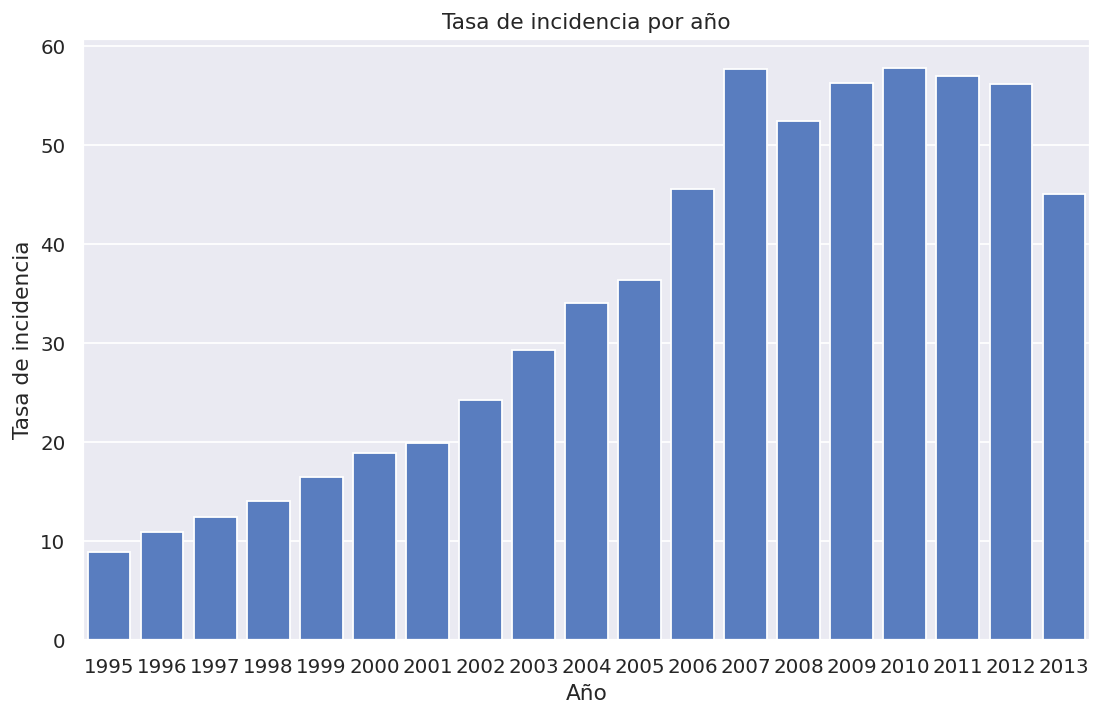

In [105]:
# Crear nuestra primera visualizacion con seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x="year", y="tasa_incidencia", data=by_year)
plt.title("Tasa de incidencia por año")
plt.xlabel("Año")
plt.ylabel("Tasa de incidencia")
# guardar la grafica en nuestro drive
plt.savefig("/content/drive/MyDrive/data/grafica_incidencia.png")

In [106]:
# grafica de barras con plotly
fig = px.bar(by_year, x="year", y="tasa_incidencia")
fig.show()